# Badanie Efektywności Reprezentacji Ortogonalnej Sygnałów 1D

---


## 1. Założenia Badawcze (Metoda Monte Carlo)
W tej części projektu odchodzimy od statycznego progu kompresji na rzecz badania **kosztu reprezentacji** sygnału. 
* **Próba:** Przeprowadzamy testy na $N=100$ niezależnych realizacjach dla każdej z 3 klas sygnałów (**APRBS**, **Multisine**, **Filtered Noise**).
* **Cel:** Wyznaczenie współczynnika $K$ – minimalnej liczby współczynników ortogonalnych niezbędnych do odtworzenia sygnału z zachowaniem **95% jego całkowitej energii**.
* **Hipoteza:** Wartość $K$ będzie zmienną losową zależną od charakterystyki sygnału. Spodziewamy się najniższych średnich wartości dla klasy *Multisine* (sygnały rzadkie w dziedzinie częstotliwości) i najwyższych dla *APRBS* (sygnały szerokopasmowe).

* **Chłopski rozum:** Wyobraź sobie, że sygnał to obraz. Szukamy odpowiedzi na pytanie: „Ile najważniejszych kolorów muszę użyć, żebyś patrząc na obraz z daleka, nie zauważył różnicy względem oryginału?”

---

## 2. Podstawy Teoretyczne

### 2.1. Transformata Fouriera (Analiza)
Dyskretna Transformata Fouriera (DFT) pozwala na dekompozycję sygnału z dziedziny czasu na sumę ortogonalnych funkcji bazowych (zespolonych wykładniczych/sinusoidalnych).



Wzór na współczynniki widmowe:
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi}{N} kn}$$

Każdy współczynnik $X[k]$ reprezentuje amplitudę i fazę składowej o konkretnej częstotliwości.

**Chłopski rozum:** Każdy sygnał to „koktajl”. Transformata to maszyna, która rozdziela go na czyste składniki i mówi Ci dokładnie, ile w tym miksie jest truskawek, a ile bananów.


### 2.2. Odwrotna Transformata Fouriera (Synteza)
Proces odwrotny pozwala na rekonstrukcję sygnału czasowego. W procesie kompresji, część współczynników $X[k]$ (te o najmniejszej energii) jest zerowana, co prowadzi do przybliżonej rekonstrukcji:

$$\hat{x}[n] = \frac{1}{N} \sum_{k=0}^{N-1} \hat{X}[k] \cdot e^{j \frac{2\pi}{N} kn}$$

**Chłopski rozum:** Z owoców spowrotem robi koktajl.

### 2.3. Mierzenie Energii i Twierdzenie Parsevala
Energia sygnału jest miarą jego zawartości informacyjnej. Zgodnie z **Twierdzeniem Parsevala**, całkowita energia w dziedzinie czasu odpowiada energii w dziedzinie częstotliwości:

$$E_{total} = \sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$

**Chłopski rozum:** Nie ważne, czy liczysz kalorie, patrząc na gotowy koktajl (czas), czy sumując kalorie każdego owocu z osobna (częstotliwość) – wynik końcowy musi być identyczny.

---

## 3. Metodyka Wyznaczania Współczynnika $K$
Aby wyznaczyć współczynnik $K$ dla progu 95%, stosujemy następującą procedurę:
1. **Obliczenie mocy:** Wyznaczamy moc poszczególnych składowych: $P[k] = |X[k]|^2$.
2. **Sortowanie:** Sortujemy moce $P[k]$ malejąco: $P_{sorted}$.
3. **Sumowanie skumulowane:** Wyznaczamy najmniejsze $K$ spełniające nierówność:
$$\frac{\sum_{i=1}^{K} P_{sorted}[i]}{E_{total}} \geq 0.95$$
4. **Wynik:** Liczba $K$ to minimalna liczba współczynników niezbędna do opisania 95% sygnału.

---

## 4. Algorytm Przetwarzania (Workflow)
Dla każdej z 100 iteracji w pętli realizujemy następujące kroki:
1. **Generowanie:** Tworzenie sygnału za pomocą klasy generatora z losowymi parametrami (amplitudy, częstotliwości, czasy utrzymania, szumy).
2. **Transformacja:** Wyznaczenie widma przy użyciu algorytmu FFT (`numpy.fft.rfft`).
3. **Analiza Energii:** Sortowanie energii współczynników i obliczenie sumy skumulowanej.
4. **Ekstrakcja K:** Zapisanie liczby współczynników $K$ niezbędnych do osiągnięcia progu 0.95 energii.
5. **Statystyka:** Wyznaczenie wartości średniej $\mu_K$ oraz odchylenia standardowego $\sigma_K$ dla każdej z grup sygnałów.

---
---
---


# KOD

## Biblioteki

In [ ]:
%matplotlib widget
# %matplotlib tk

from matplotlib import pyplot as plt
from DatasetCreator import DatasetCreator
from Plotter import Plotter 
from Fourier import Fourier, Fourier2
from EnergyAnalyzer import EnergyAnalyzer
from FidelityAnalyzer import FidelityAnalyzer
import numpy as np

## Generacja sygnałów
Dodatkowo przykładowe wykresy

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie NOISE: 100%|██████████| 10/10 [00:00<00:00, 372.70it/s]


--- Generowanie zakończone ---
Kategoria APRBS: 10 sygnałów
Kategoria MULTISINE: 10 sygnałów
Kategoria NOISE: 10 sygnałów

=== Kategoria: APRBS ===
Trajektoria nr 1:
  t (pierwsze 5): [0.  0.1 0.2 0.3 0.4]
  y (pierwsze 5): [79.07592497 79.07592497 79.07592497 79.07592497 79.07592497]
  Długość wektora: 5000 próbek
------------------------------

=== Kategoria: MULTISINE ===
Trajektoria nr 1:
  t (pierwsze 5): [0.  0.1 0.2 0.3 0.4]
  y (pierwsze 5): [54.23853407 54.30043798 54.36184292 54.42274354 54.48313453]
  Długość wektora: 5000 próbek
------------------------------

=== Kategoria: NOISE ===
Trajektoria nr 1:
  t (pierwsze 5): [0.  0.1 0.2 0.3 0.4]
  y (pierwsze 5): [55.63380935 57.74945928 59.67224327 60.47926613 57.6440316 ]
  Długość wektora: 5000 próbek
------------------------------


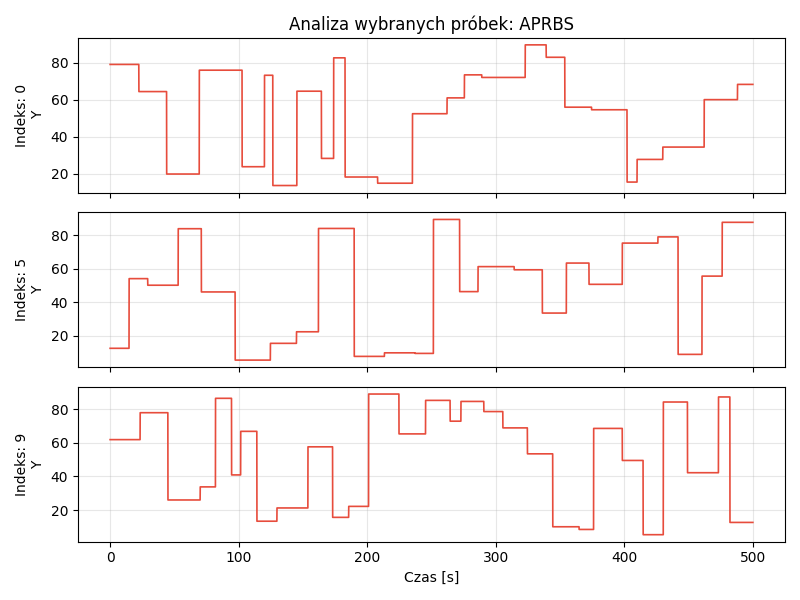

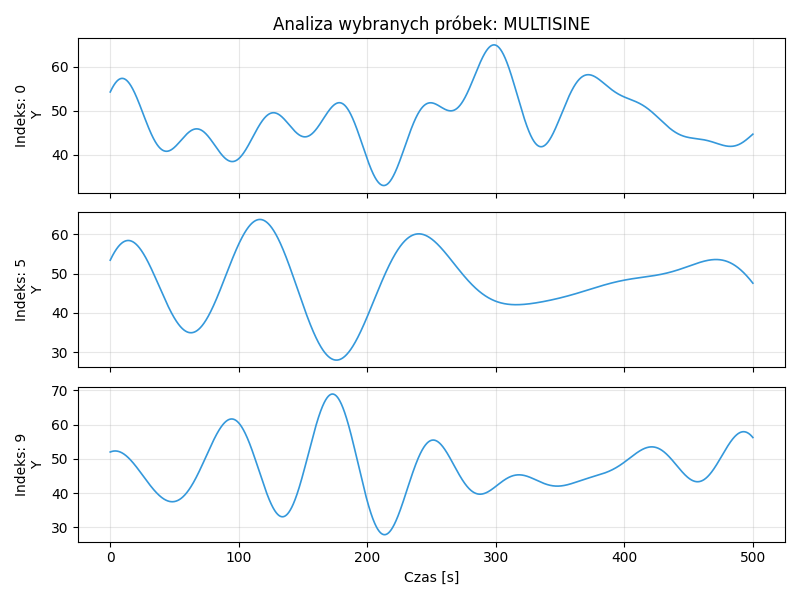

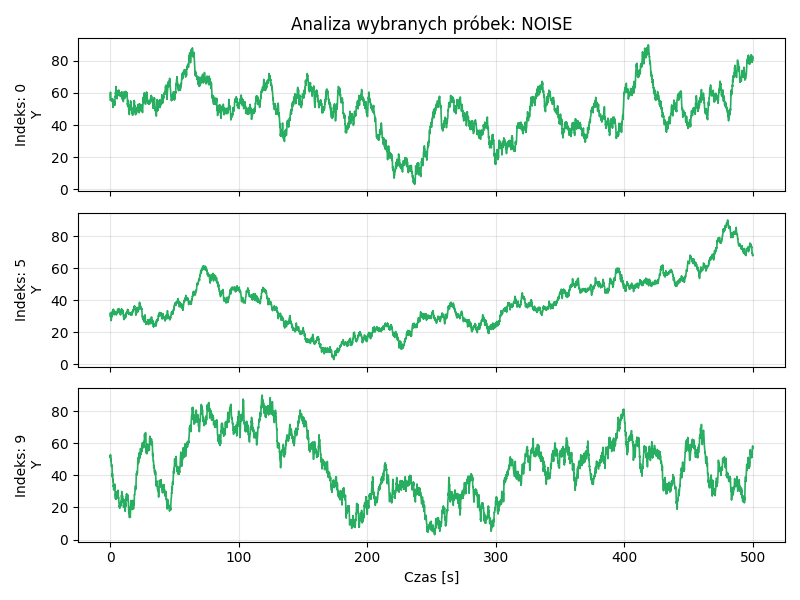

In [2]:
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

for category, signals in dataset.items():
    print(f"\n=== Kategoria: {category.upper()} ===")
    for i, traj in enumerate(signals[:1]):  # Pokazujemy tylko 1 przykład
        print(f"Trajektoria nr {i+1}:")
        print(f"  t (pierwsze 5): {traj.t[:5]}")
        print(f"  y (pierwsze 5): {traj.y[:5]}")
        print(f"  Długość wektora: {len(traj.y)} próbek")
        print("-" * 30)

# Rysowanie
# Chcę porównać pierwszy, środkowy i ostatni sygnał ze wszystkich kategorii 
Plotter.plot_indices(dataset['aprbs'], "aprbs", indices=[0, 5, 9])

Plotter.plot_indices(dataset['multisine'], "multisine", indices=[0, 5, 9])

Plotter.plot_indices(dataset['noise'], "noise", indices=[0, 5, 9])

## FOURIER (NOWY)

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie NOISE: 100%|██████████| 10/10 [00:00<00:00, 271.56it/s]


--- Generowanie zakończone ---
Kategoria APRBS: 10 sygnałów
Kategoria MULTISINE: 10 sygnałów
Kategoria NOISE: 10 sygnałów
--- Transformaty dla omega w zakresie [-5.0, 5.0] ---


Omega  (pierwsze 5): [-1.09621594+0.77746424j  0.07969983+0.02200266j  1.14573288+0.93459944j
  0.57930641+2.22226559j -0.8173245 +2.05132731j]


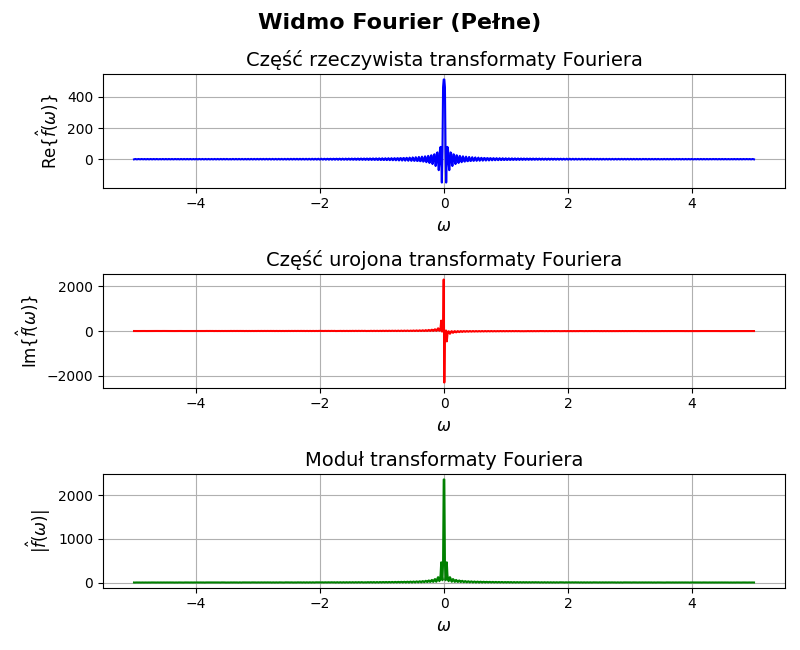

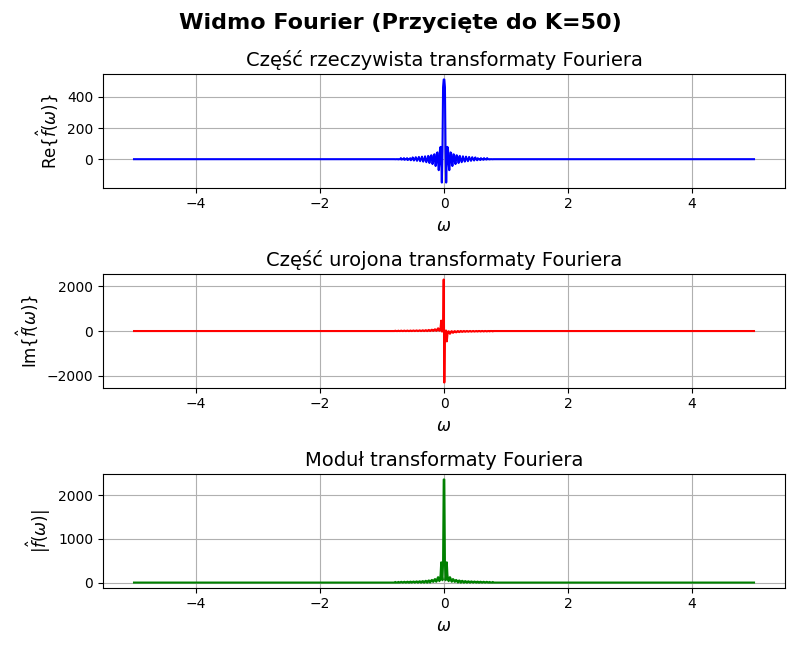

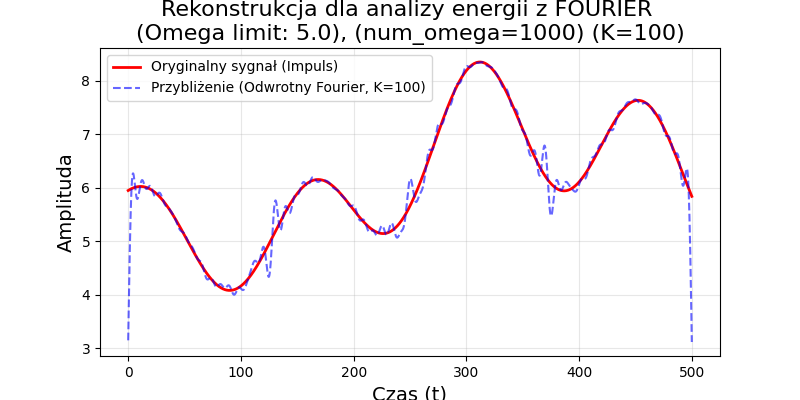

In [3]:
# 1. Generujemy dane
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 9), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

# sample_signal = dataset['aprbs'][0]  # Pobieramy pierwszy sygnał z kategorii APRBS
sample_signal = dataset['multisine'][0]  # Pobieramy pierwszy sygnał z kategorii MULTISINE


# 2. Inicjalizacja klasy Fourier
fourier_engine = Fourier(sample_signal.t, sample_signal.y)

# Parametry analizy
omega_limit = 5.0  # Zakres częstotliwości do analizy
num_omega = 1000  # Liczba punktów w zakresie omega - Używamy mniejszego num_omega dla szybkości lub większego dla precyzji
k=100  # Liczba współczynników do zachowania (przycinanie)

print(f"--- Transformaty dla omega w zakresie [-{omega_limit}, {omega_limit}] ---")

# 3. Obliczenie transformaty prostej dla zakresu częstotliwości
omega_vec, f_omega_vec = fourier_engine.transform(omega_limit=omega_limit, num_omega=num_omega)
print(f"Omega  (pierwsze 5): {f_omega_vec[:5]}")

# 4. Przycinamy do 50 najważniejszych współczynników (K=50)
f_trimmed = fourier_engine.trim_spectrum(omega_vec=omega_vec, f_omega_vec=f_omega_vec, k=k)

# 4. Obliczenie transformaty odwrotnej (rekonstrukcja sygnału)
y_reconstructed = fourier_engine.inverse_transform(omega_vec, f_trimmed)

# 5. Wizualizacja wyników
# Wykres widma (Część rzeczywista, urojona i moduł)
Plotter.plot_fourier_transform(omega_vec, f_omega_vec, title="Widmo Fourier (Pełne)")
Plotter.plot_fourier_transform(omega_vec, f_trimmed, title="Widmo Fourier (Przycięte do K=50)")

# Wykres porównawczy (Oryginał vs Rekonstrukcja)
Plotter.plot_fourier_comparison(
    sample_signal.t, 
    sample_signal.y, 
    y_reconstructed, 
    K=k,
    title=f"Rekonstrukcja dla analizy energii z FOURIER \n(Omega limit: {omega_limit}), (num_omega={num_omega}) (K={k})"
)


## FOURIER (STARY)

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie NOISE: 100%|██████████| 10/10 [00:00<00:00, 263.73it/s]


--- Generowanie zakończone ---
Kategoria APRBS: 10 sygnałów
Kategoria MULTISINE: 10 sygnałów
Kategoria NOISE: 10 sygnałów


--- Transformaty dla omega w zakresie [-5.0, 5.0] ---
Omega  (pierwsze 5): [-10.33686478+6.99331400e+00j  10.75362717+8.38955427e+00j
  -7.56247789+1.91456096e+01j   1.67208571-7.72342238e-03j
   4.75999326+2.12022299e+01j]


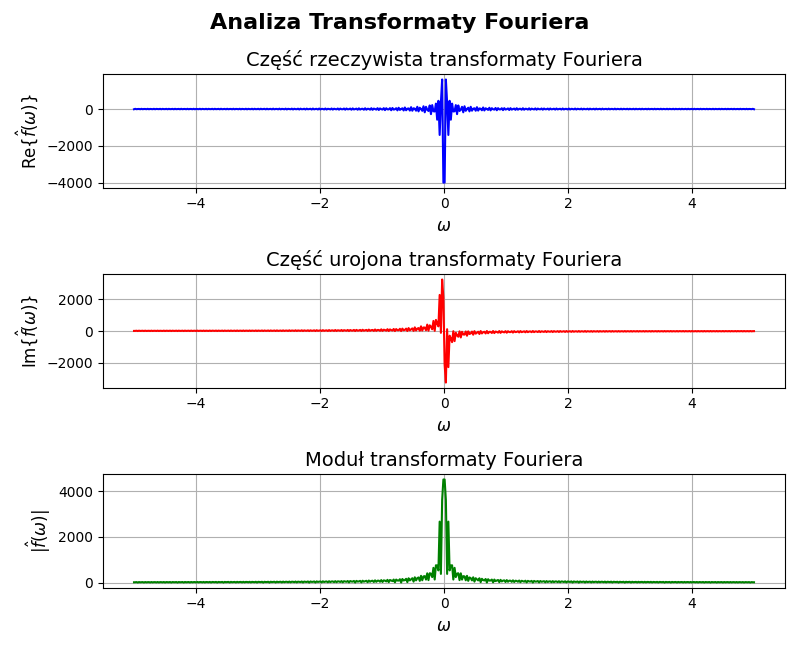

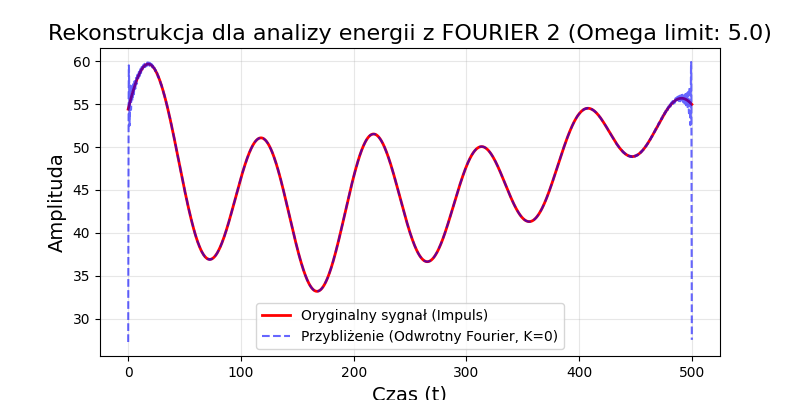

In [4]:
# 1. Generujemy dane
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

sample_signal = dataset['multisine'][0]  # Pobieramy pierwszy sygnał z kategorii MULTISINE

# 2. Inicjalizacja klasy Fourier
fourier_engine = Fourier2(sample_signal.t, sample_signal.y)

# 3. Obliczenie transformaty prostej dla zakresu częstotliwości
omega_limit = 5.0  # Zakres częstotliwości do analizy
omega_vec = np.linspace(-omega_limit, omega_limit, 500)
f_omega = fourier_engine.transform(omega_vec)

print(f"--- Transformaty dla omega w zakresie [-{omega_limit}, {omega_limit}] ---")
print(f"Omega  (pierwsze 5): {f_omega[:5]}")

# 4. Obliczenie transformaty odwrotnej (rekonstrukcja sygnału)
# Używamy mniejszego num_omega dla szybkości lub większego dla precyzji
y_reconstructed = fourier_engine.inverse_transform(
    omega_limit=omega_limit, 
    num_omega=1000
)

# 5. Wizualizacja wyników
# Wykres widma (Część rzeczywista, urojona i moduł)
Plotter.plot_fourier_transform(omega_vec, f_omega)

# Wykres porównawczy (Oryginał vs Rekonstrukcja)
Plotter.plot_fourier_comparison(
    sample_signal.t, 
    sample_signal.y, 
    y_reconstructed, 
    K=0,
    title=f"Rekonstrukcja dla analizy energii z FOURIER 2 (Omega limit: {omega_limit})"
)


## ANALIZA ENERGII

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie NOISE: 100%|██████████| 10/10 [00:00<00:00, 338.97it/s]



--- Generowanie zakończone ---
Kategoria APRBS: 10 sygnałów
Kategoria MULTISINE: 10 sygnałów
Kategoria NOISE: 10 sygnałów

--- ANALIZA SYGNAŁU MULTISINE ---
Energia w dziedzinie czasu: 12586340.79
Wspołczynniki FFT - liczba: 2501...
Wspołczynniki FFT: [246533.24699222    +0.j          -4618.22768629-17937.48342256j
  13728.77906516 -1966.35432117j  -2687.02737665 -8558.29981597j
   6783.70394208+17689.70504808j]...
Energia w dziedzinie częstotliwości: 12371034.59
Liczba współczynników (K) dla 99.9% energii: 6

--- Transformaty dla omega w zakresie [-5.0, 5.0] ---


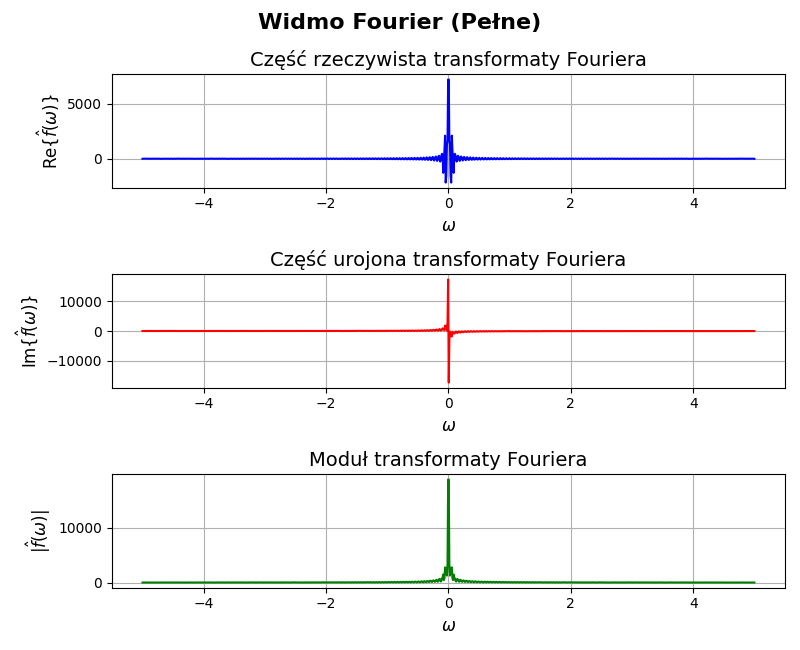

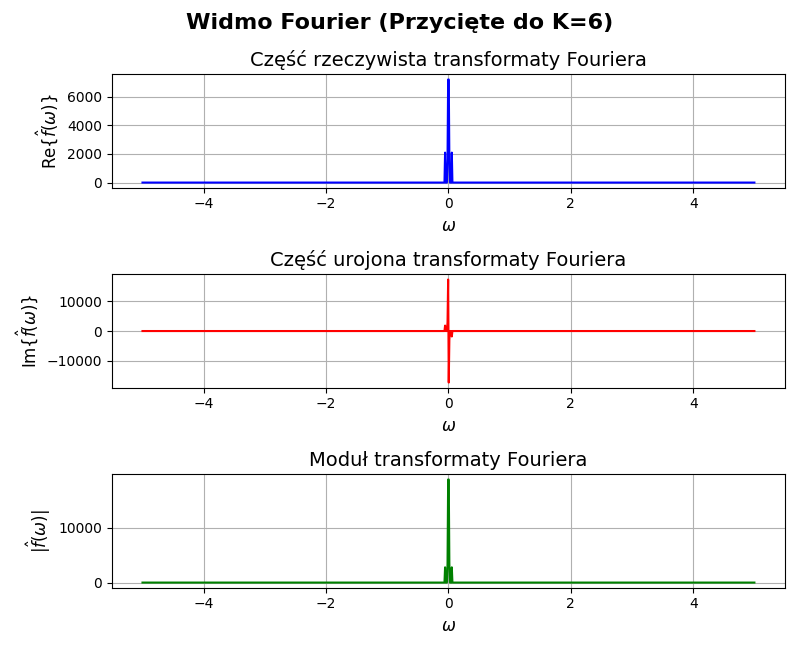

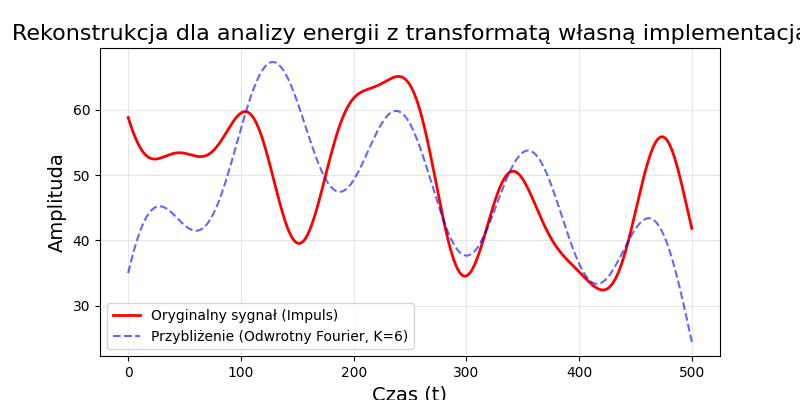

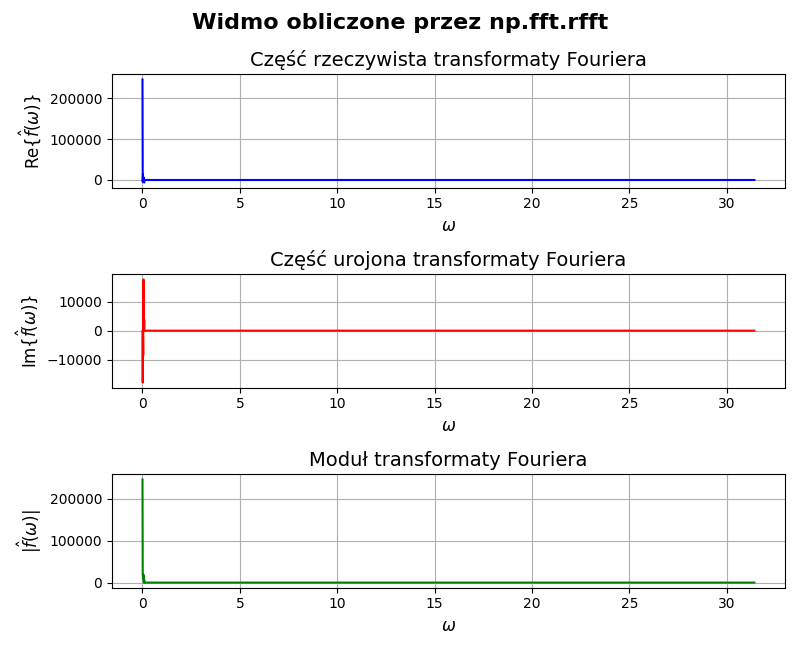

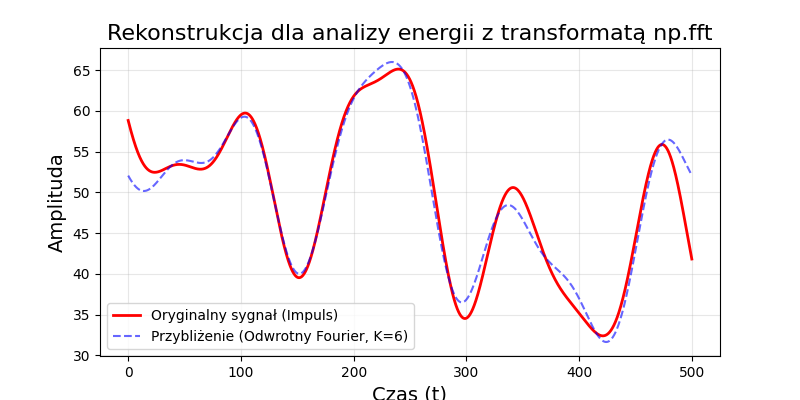

In [5]:
# 1. Generujemy dane
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

print("\n--- ANALIZA SYGNAŁU MULTISINE ---")# Pobieramy pierwszy sygnał z listy
signal = dataset['multisine'][0] 

# 2. Analiza energii w dziedzinie czasu
e_time = EnergyAnalyzer.calculate_total_energy(signal)
print(f"Energia w dziedzinie czasu: {e_time:.2f}")

# 3. Analiza energii w dziedzinie częstotliwości (FFT)
coeffs = np.fft.rfft(signal.y)
# Częstotliwości odpowiadające współczynnikom (w Hz lub rad/s)
freqs = np.fft.rfftfreq(len(signal.y), d=(signal.t[1] - signal.t[0]))
omega_numpy = 2 * np.pi * freqs

results = EnergyAnalyzer.analyze_energy_distribution(coeffs, N=len(signal.y), threshold=0.999)
print(f"Wspołczynniki FFT - liczba: {len(coeffs)}...")  # Pokazujemy tylko pierwsze 5 współczynników
print(f"Wspołczynniki FFT: {coeffs[:5]}...")  # Pokazujemy tylko pierwsze 5 współczynników
print(f"Energia w dziedzinie częstotliwości: {results['total_energy_freq']:.2f}")
print(f"Liczba współczynników (K) dla 99.9% energii: {results['k_threshold']}")

# PRÓBA ANALIZY Z KLASY FOURIER (DLA K LICZBY WSPÓŁCZYNNIKÓW DLA 99.9% ENERGII)

# 4. Inicjalizacja klasy Fourier
fourier_engine = Fourier(signal.t, signal.y)

# Parametry analizy
omega_limit = 5.0  # Zakres częstotliwości do analizy
num_omega = 1000  # Liczba punktów w zakresie omega - Używamy mniejszego num_omega dla szybkości lub większego dla precyzji
print(f"\n--- Transformaty dla omega w zakresie [-{omega_limit}, {omega_limit}] ---")

# 5. Obliczenie transformaty prostej dla zakresu częstotliwości
omega_vec, f_omega_vec = fourier_engine.transform(omega_limit=omega_limit, num_omega=num_omega)

# 6. Przycinamy do 50 najważniejszych współczynników (K=50)
f_trimmed = fourier_engine.trim_spectrum(omega_vec=omega_vec, f_omega_vec=f_omega_vec, k=results['k_threshold'])

# 7. Obliczenie transformaty odwrotnej (rekonstrukcja sygnału)
y_reconstructed = fourier_engine.inverse_transform(omega_vec, f_trimmed)

# 8. Wizualizacja wyników
# Wykres widma (Część rzeczywista, urojona i moduł)
Plotter.plot_fourier_transform(omega_vec, f_omega_vec, title="Widmo Fourier (Pełne)")
Plotter.plot_fourier_transform(omega_vec, f_trimmed, title=f"Widmo Fourier (Przycięte do K={results['k_threshold']})")

# Wykres porównawczy (Oryginał vs Rekonstrukcja)
Plotter.plot_fourier_comparison(
    signal.t, 
    signal.y, 
    y_reconstructed, 
    K=results['k_threshold'],
    title=f"Rekonstrukcja dla analizy energii z transformatą własną implementacją"
)

# PRÓBA ANALIZY Z NUMPY FOURIER (DLA K LICZBY WSPÓŁCZYNNIKÓW DLA 99.9% ENERGII)

# 9. Przycinanie widma (metoda analogiczna do trim_spectrum)
# Sortujemy po amplitudzie i zostawiamy tylko K największych, reszta -> 0
magnitudes = np.abs(coeffs)
# Pobieramy próg wartości dla k-tego największego elementu
threshold_val = np.sort(magnitudes)[-results['k_threshold']]
coeffs_trimmed = np.where(magnitudes >= threshold_val, coeffs, 0)

# 10. Transformata odwrotna (Inverse Real FFT)
# irfft automatycznie odtwarza sygnał o długości N na podstawie współczynników rfft
y_reconstructed_np = np.fft.irfft(coeffs_trimmed, n=len(signal.y))

# 11. Wizualizacja wyników
# Wykres widma (Część rzeczywista, urojona i moduł)
Plotter.plot_fourier_transform(omega_numpy, coeffs_trimmed, title="Widmo obliczone przez np.fft.rfft")

# Wykres porównawczy (Oryginał vs Rekonstrukcja)
# 3. Rysujesz wynik
Plotter.plot_fourier_comparison(
    signal.t, 
    signal.y, 
    y_reconstructed_np, 
    K=results['k_threshold'],
    title=f"Rekonstrukcja dla analizy energii z transformatą np.fft"
)


## ANALIZA DOKŁADNOŚCI

--- Start generowania zestawu danych (Noise Level: 0.0) ---


Generowanie NOISE: 100%|██████████| 10/10 [00:00<00:00, 311.08it/s]


--- Generowanie zakończone ---
Kategoria APRBS: 10 sygnałów
Kategoria MULTISINE: 10 sygnałów
Kategoria NOISE: 10 sygnałów

--- ANALIZA SYGNAŁU MULTISINE ---
Aby błąd maksymalny był < 2.0, potrzeba K = 147


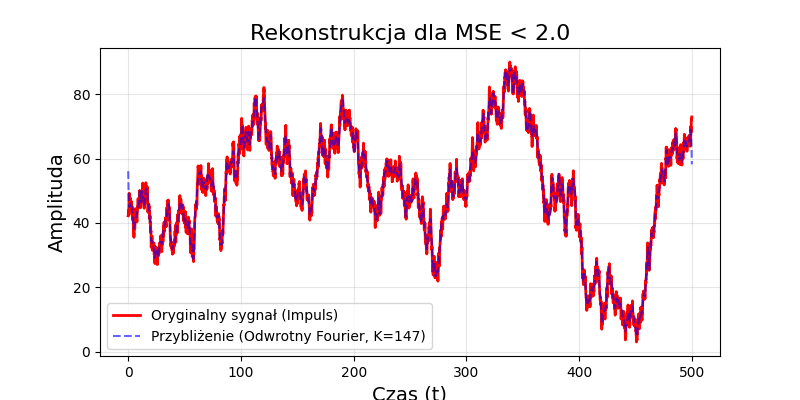

In [5]:
# 1. Generujemy dane
creator = DatasetCreator(t_span=[0, 500], dt=0.1, amp_range=(3, 90), noise_level=0.0)
dataset = creator.create_dataset(n_aprbs=10, n_multisine=10, n_noise=10)

print("\n--- ANALIZA SYGNAŁU MULTISINE ---")# Pobieramy pierwszy sygnał z listy
signal = dataset['noise'][0] # multisine, arbs, noise

# 1. Obliczasz FFT za pomocą numpy
coeffs = np.fft.rfft(signal.y)

# 2. Szukasz K dla Max Error = 2.0 (czyli niebieska linia ma być b. blisko czerwonej)
# Ustaw próg dopasowany do Twojej amp_range (np. 3-5% amplitudy sygnału)
max_allowed_diff = 2.0 
mode = 'mse'  # Można użyć 'max_error' aby sprawdzać maksymalny błąd albo 'mse' aby sprawdzać średni błąd kwadratowy
results = FidelityAnalyzer.analyze_by_error(signal.y, coeffs, threshold=max_allowed_diff, mode=mode)

print(f"Aby błąd maksymalny był < {max_allowed_diff}, potrzeba K = {results['k_threshold']}")

# 3. Rysujesz wynik
Plotter.plot_fourier_comparison(
    signal.t, 
    signal.y, 
    results['reconstructed_y'], 
    K=results['k_threshold'],
    title=f"Rekonstrukcja dla {mode.upper()} < {max_allowed_diff}"
)

## COŚ

In [ ]:
import numpy as np
import scipy.fftpack as fftpack
import matplotlib.pyplot as plt

# 1. Tworzymy sygnał testowy (suma sinusów - model prostego dźwięku)
N = 512
t = np.linspace(0, 1, N)
signal = np.sin(2 * np.pi * 5 * t) + 0.5 * np.sin(2 * np.pi * 20 * t) + 0.2 * np.random.randn(N)

# 2. Obliczamy współczynniki w dwóch bazach
# FFT (Fourier) - bierzemy moduł, bo FFT daje liczby zespolone
coef_fft = np.abs(np.fft.rfft(signal)) 
# DCT (Kosinusowa) - standard w audio
coef_dct = np.abs(fftpack.dct(signal, norm='ortho'))

# 3. Funkcja do obliczania skumulowanej energii (zbieżności)
def get_energy_convergence(coeffs):
    # Sortujemy współczynniki od największego (najważniejszego) do najmniejszego
    sorted_coeffs = np.sort(np.abs(coeffs))[::-1]
    # Liczymy sumę skumulowaną kwadratów (energia to kwadrat amplitudy)
    energy_cumulative = np.cumsum(sorted_coeffs**2)
    # Normalizujemy do 1.0 (czyli do 100%)
    return energy_cumulative / energy_cumulative[-1]

# 4. Obliczamy krzywe zbieżności
energy_fft = get_energy_convergence(coef_fft)
energy_dct = get_energy_convergence(coef_dct)

# 5. Wykres porównawczy
plt.figure(figsize=(10, 5))
plt.plot(energy_dct[:100], label='Baza DCT (Kosinusowa)', linewidth=2)
plt.plot(energy_fft[:100], label='Baza FFT (Fouriera)', linestyle='--')
plt.axhline(y=0.95, color='r', alpha=0.3, label='Próg 95% energii')
plt.title("Porównanie zbieżności energii (pierwsze 100 współczynników)")
plt.xlabel("Liczba użytych współczynników")
plt.ylabel("Ułamek całkowitej energii")
plt.legend()
plt.grid(True)
plt.show()